# [SUPER FINAL REANNOTATED] Mask R-CNN + FPN with COCO Transfer Learning


### 1. Mount Google Drive

PROJECT_ROOT = "/content/drive/MyDrive/Thesis2"

FPS6_RAW_VIDEOS_PATH = "/content/drive/MyDrive/Thesis2/Thesis2_6fpsRawVideos"

DATASET_RAW_PATH = "/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset"

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis2")

FPS6_RAW_VIDEOS_PATH = PROJECT_ROOT / "Thesis2_6fpsRawVideos"

DATASET_RAW_PATH = PROJECT_ROOT / "Thesis2_SUPER_FINAL_REANNOTATED_RawDataset"

In [3]:
print("Project folder exists:", PROJECT_ROOT.exists())
print("Project folder exists:", FPS6_RAW_VIDEOS_PATH.exists())
print("Project folder exists:", DATASET_RAW_PATH.exists())

Project folder exists: True
Project folder exists: True
Project folder exists: True


In [4]:
!ls "/content/drive/MyDrive/Thesis2/"

error_analysis_IS_FPN_best_model
original_split_manifest.csv
outputs_maskrcnn_fpn
outputs_maskrcnn_fpn_final_reannotated
outputs_maskrcnn_fpn_reannotated
outputs_maskrcnn_fpn_sunset_only
outputs_maskrcnn_fpn_super_final_reannotated
outputs_zero3dce
outputs_zero3dce_v3sofia
split_comparison_reports
Thesis2_6fpsRawVideos
Thesis2_FINAL_REANNOTATED_RawDataset
Thesis2_RawDataset
Thesis2_REANNOTATED_RawDataset
Thesis2_SUNSET_RawDataset
Thesis2_SUPER_FINAL_REANNOTATED_RawDataset


In [5]:
!ls "/content/drive/MyDrive/Thesis2/Thesis2_FINAL_REANNOTATED_RawDataset/"

test  train  valid


In [6]:
!ls "/content/drive/MyDrive/Thesis2/Thesis2_FINAL_REANNOTATED_RawDataset/train"

evening  midnight  sunset


In [7]:
!ls "/content/drive/MyDrive/Thesis2/Thesis2_FINAL_REANNOTATED_RawDataset/train/evening"

_annotations.coco.json
evening_6fps_mp4-0001_jpg.rf.7942217fe1dbe07f0e5fdbeddb0169cc.jpg
evening_6fps_mp4-0002_jpg.rf.dec48a2a275965ea8f093fccf4155157.jpg
evening_6fps_mp4-0003_jpg.rf.8c1ba6034abb1799ea8958bba72dd4fa.jpg
evening_6fps_mp4-0005_jpg.rf.cfa5c2854fe342c17d704011b156ae7d.jpg
evening_6fps_mp4-0007_jpg.rf.4c9d8077a9095fb7ffd1528202251b00.jpg
evening_6fps_mp4-0015_jpg.rf.4be047de965e56237cd0344f3ef68da1.jpg
evening_6fps_mp4-0024_jpg.rf.a309432ff45219ab79b017f00410b9ab.jpg
evening_6fps_mp4-0025_jpg.rf.53aea042c3ee53850249110dfd3c9dce.jpg
evening_6fps_mp4-0026_jpg.rf.fa48098d220d88e39e25bf843f3c81b1.jpg
evening_6fps_mp4-0029_jpg.rf.35aa5af22c6d3ab38029d1024c758995.jpg
evening_6fps_mp4-0035_jpg.rf.1b6b5d71a47d6fd00109e406fa4ec13f.jpg
evening_6fps_mp4-0046_jpg.rf.36f1d87e237aecc87eb43f597bc57665.jpg
evening_6fps_mp4-0059_jpg.rf.571afe9f29e9408943631dad849ff133.jpg
evening_6fps_mp4-0060_jpg.rf.06f8cb29eacb0cb8e5f61dbdd9a9f546.jpg
evening_6fps_mp4-0063_jpg.rf.160ff1885bd937068b4d484e

### 2. Libraries and Paths

TRAIN_PATH = DATASET_RAW_PATH / "train"

VALID_PATH = DATASET_RAW_PATH / "valid"

TEST_PATH  = DATASET_RAW_PATH / "test"

OUTPUT_DIR = PROJECT_ROOT / "outputs_maskrcnn_fpn_super_final_reannotated"

In [8]:
TRAIN_PATH = DATASET_RAW_PATH / "train"
VALID_PATH = DATASET_RAW_PATH / "valid"
TEST_PATH  = DATASET_RAW_PATH / "test"

OUTPUT_DIR = PROJECT_ROOT / "outputs_maskrcnn_fpn_super_final_reannotated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root exists:", PROJECT_ROOT.exists())
print("Dataset exists:", DATASET_RAW_PATH.exists())
print("Train exists:", TRAIN_PATH.exists())
print("Valid exists:", VALID_PATH.exists())
print("Test exists:", TEST_PATH.exists())
print("Output folder:", OUTPUT_DIR)

Project root exists: True
Dataset exists: True
Train exists: True
Valid exists: True
Test exists: True
Output folder: /content/drive/MyDrive/Thesis2/outputs_maskrcnn_fpn_super_final_reannotated


In [9]:
for split_path in [TRAIN_PATH, VALID_PATH, TEST_PATH]:
    print(f"\n{split_path.name}:")
    for folder in sorted(split_path.iterdir()):
        if folder.is_dir():
            print(" -", folder.name)


train:
 - evening
 - midnight
 - sunset

valid:
 - evening
 - midnight
 - sunset

test:
 - evening
 - midnight
 - sunset


In [10]:
!pip install -q pycocotools

In [11]:
import os
import json
import random
import numpy as np
import cv2
import torch
import torchvision
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter
from pycocotools import mask as maskUtils

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision.transforms import functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
Device: cuda


In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### 3. COCO Preparation

In [13]:
def find_coco_jsons(split_path):
    return sorted(split_path.rglob("_annotations.coco.json"))

train_jsons = find_coco_jsons(TRAIN_PATH)
valid_jsons = find_coco_jsons(VALID_PATH)
test_jsons  = find_coco_jsons(TEST_PATH)

print("Train JSONs:", len(train_jsons))
print("Valid JSONs:", len(valid_jsons))
print("Test JSONs:", len(test_jsons))

print("\nTrain annotation files:")
for p in train_jsons:
    print(p)

print("\nValid annotation files:")
for p in valid_jsons:
    print(p)

print("\nTest annotation files:")
for p in test_jsons:
    print(p)

Train JSONs: 3
Valid JSONs: 3
Test JSONs: 3

Train annotation files:
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/train/evening/_annotations.coco.json
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/train/midnight/_annotations.coco.json
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/train/sunset/_annotations.coco.json

Valid annotation files:
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/valid/evening/_annotations.coco.json
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/valid/midnight/_annotations.coco.json
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/valid/sunset/_annotations.coco.json

Test annotation files:
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/test/evening/_annotations.coco.json
/content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/test/midnight/_annotations.coco.

In [14]:
def inspect_categories(coco_json_paths):
    categories = {}

    for json_path in coco_json_paths:
        with open(json_path, "r") as f:
            data = json.load(f)

        for cat in data["categories"]:
            categories[cat["name"]] = cat["id"]

    return categories

raw_categories = inspect_categories(train_jsons + valid_jsons + test_jsons)

print("Raw Roboflow categories:")
for name, cat_id in raw_categories.items():
    print(cat_id, ":", name)

Raw Roboflow categories:
0 : Dataset-Annotation
1 : car
2 : motorcycle
3 : person
4 : unknown object


In [15]:
IGNORED_CLASSES = {
    "Dataset-Annotation",
    "dataset-annotation",
    "Dataset Annotation",
    "dataset annotation",
    "unknown object",
    "unknown_object",
    "Unknown Object",
    "Unknown_Object"
}

CANONICAL_CLASS_NAME = {
    "car": "car",
    "motorcycle": "motorcycle",
    "person": "person"
}

CLASS_NAMES = [
    "car",
    "motorcycle",
    "person"
]

class_to_idx = {
    "car": 1,
    "motorcycle": 2,
    "person": 3
}

idx_to_class = {
    1: "car",
    2: "motorcycle",
    3: "person"
}

NUM_CLASSES = len(CLASS_NAMES) + 1

print("Final Mask R-CNN class mapping:")
print("0 : background")
for idx, name in idx_to_class.items():
    print(idx, ":", name)

print("NUM_CLASSES:", NUM_CLASSES)

Final Mask R-CNN class mapping:
0 : background
1 : car
2 : motorcycle
3 : person
NUM_CLASSES: 4


In [16]:
def inspect_categories(coco_json_paths):
    categories = {}

    for json_path in coco_json_paths:
        with open(json_path, "r") as f:
            data = json.load(f)

        for cat in data["categories"]:
            categories[cat["name"]] = cat["id"]

    return categories

raw_categories = inspect_categories(train_jsons + valid_jsons + test_jsons)

print("Raw categories found:")
for name, cat_id in raw_categories.items():
    print(cat_id, ":", name)

Raw categories found:
0 : Dataset-Annotation
1 : car
2 : motorcycle
3 : person
4 : unknown object


In [17]:
def validate_label_policy(coco_json_paths):
    accepted = set(CANONICAL_CLASS_NAME.keys())
    ignored = set(IGNORED_CLASSES)

    found = set()

    for json_path in coco_json_paths:
        with open(json_path, "r") as f:
            data = json.load(f)

        for cat in data["categories"]:
            found.add(cat["name"])

    unknown = found - accepted - ignored

    print("Found classes:", found)
    print("Accepted classes:", accepted)
    print("Ignored classes:", ignored)

    if unknown:
        print("\nWARNING: These classes are neither accepted nor ignored:")
        for name in unknown:
            print("-", name)
    else:
        print("\nAll classes are accounted for.")

validate_label_policy(train_jsons + valid_jsons + test_jsons)

Found classes: {'unknown object', 'person', 'Dataset-Annotation', 'car', 'motorcycle'}
Accepted classes: {'person', 'car', 'motorcycle'}
Ignored classes: {'Dataset Annotation', 'dataset annotation', 'Unknown Object', 'Unknown_Object', 'unknown object', 'unknown_object', 'Dataset-Annotation', 'dataset-annotation'}

All classes are accounted for.


In [18]:
def count_usable_annotations(coco_json_paths):
    total_annotations = 0
    usable_annotations = 0
    ignored_annotations = 0

    usable_by_class = {name: 0 for name in CLASS_NAMES}
    ignored_by_class = {}

    for json_path in coco_json_paths:
        with open(json_path, "r") as f:
            data = json.load(f)

        categories = {cat["id"]: cat["name"] for cat in data["categories"]}

        for ann in data["annotations"]:
            total_annotations += 1

            raw_name = categories.get(ann["category_id"], None)

            if raw_name in IGNORED_CLASSES:
                ignored_annotations += 1
                ignored_by_class[raw_name] = ignored_by_class.get(raw_name, 0) + 1
                continue

            if raw_name not in CANONICAL_CLASS_NAME:
                ignored_annotations += 1
                ignored_by_class[raw_name] = ignored_by_class.get(raw_name, 0) + 1
                continue

            canonical_name = CANONICAL_CLASS_NAME[raw_name]

            if canonical_name not in class_to_idx:
                ignored_annotations += 1
                ignored_by_class[raw_name] = ignored_by_class.get(raw_name, 0) + 1
                continue

            usable_annotations += 1
            usable_by_class[canonical_name] += 1

    print("Total annotations:", total_annotations)
    print("Usable annotations:", usable_annotations)
    print("Ignored annotations:", ignored_annotations)

    print("\nUsable annotations by class:")
    for k, v in usable_by_class.items():
        print(k, ":", v)

    print("\nIgnored annotations by class:")
    for k, v in ignored_by_class.items():
        print(k, ":", v)

count_usable_annotations(train_jsons + valid_jsons + test_jsons)

Total annotations: 11617
Usable annotations: 8961
Ignored annotations: 2656

Usable annotations by class:
car : 3951
motorcycle : 2301
person : 2709

Ignored annotations by class:
unknown object : 2656


In [19]:
def validate_coco_dataset(coco_json_paths, max_print=20):
    total_images = 0
    total_annotations = 0

    missing_images = []
    empty_segmentations = []
    bad_bboxes = []
    dimension_mismatches = []

    for json_path in coco_json_paths:
        folder = json_path.parent

        with open(json_path, "r") as f:
            data = json.load(f)

        total_images += len(data["images"])
        total_annotations += len(data["annotations"])

        categories = {cat["id"]: cat["name"] for cat in data["categories"]}

        for img in data["images"]:
            img_path = folder / img["file_name"]

            if not img_path.exists():
                missing_images.append(str(img_path))
                continue

            try:
                actual = Image.open(img_path).convert("RGB")
                actual_w, actual_h = actual.size

                coco_w = img.get("width")
                coco_h = img.get("height")

                if coco_w is not None and coco_h is not None:
                    if int(coco_w) != actual_w or int(coco_h) != actual_h:
                        dimension_mismatches.append(
                            (str(img_path), (coco_w, coco_h), (actual_w, actual_h))
                        )

            except Exception as e:
                missing_images.append(f"{img_path} | cannot open: {e}")

        for ann in data["annotations"]:
            raw_name = categories.get(ann["category_id"], None)

            if raw_name in IGNORED_CLASSES:
                continue

            if raw_name not in CANONICAL_CLASS_NAME:
                continue

            bbox = ann.get("bbox", None)
            seg = ann.get("segmentation", None)

            if seg is None or seg == []:
                empty_segmentations.append((str(json_path), ann.get("id"), raw_name))

            if bbox is None or len(bbox) != 4:
                bad_bboxes.append((str(json_path), ann.get("id"), raw_name, bbox))
            else:
                x, y, w, h = bbox
                if w <= 0 or h <= 0:
                    bad_bboxes.append((str(json_path), ann.get("id"), raw_name, bbox))

    print("Total images:", total_images)
    print("Total annotations:", total_annotations)
    print("Missing/unreadable images:", len(missing_images))
    print("Empty segmentations:", len(empty_segmentations))
    print("Bad bboxes:", len(bad_bboxes))
    print("Dimension mismatches:", len(dimension_mismatches))

    if missing_images:
        print("\nMissing image samples:")
        for item in missing_images[:max_print]:
            print(item)

    if empty_segmentations:
        print("\nEmpty segmentation samples:")
        for item in empty_segmentations[:max_print]:
            print(item)

    if bad_bboxes:
        print("\nBad bbox samples:")
        for item in bad_bboxes[:max_print]:
            print(item)

    if dimension_mismatches:
        print("\nDimension mismatch samples:")
        for item in dimension_mismatches[:max_print]:
            print(item)

validate_coco_dataset(train_jsons + valid_jsons + test_jsons)

Total images: 1726
Total annotations: 11617
Missing/unreadable images: 0
Empty segmentations: 0
Bad bboxes: 0
Dimension mismatches: 0


In [20]:
class ThesisCocoSegmentationDataset(Dataset):
    def __init__(
        self,
        coco_json_paths,
        class_to_idx,
        canonical_class_name,
        ignored_classes,
        min_area=25,
        keep_empty_images=False
    ):
        self.class_to_idx = class_to_idx
        self.canonical_class_name = canonical_class_name
        self.ignored_classes = ignored_classes
        self.min_area = min_area
        self.keep_empty_images = keep_empty_images
        self.samples = []

        for json_path in coco_json_paths:
            json_path = Path(json_path)
            image_dir = json_path.parent

            with open(json_path, "r") as f:
                coco = json.load(f)

            categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
            images = {img["id"]: img for img in coco["images"]}

            anns_by_image = {}
            for ann in coco["annotations"]:
                image_id = ann["image_id"]
                anns_by_image.setdefault(image_id, []).append(ann)

            for image_id, img_info in images.items():
                img_path = image_dir / img_info["file_name"]

                if not img_path.exists():
                    continue

                raw_anns = anns_by_image.get(image_id, [])

                usable_count = 0

                for ann in raw_anns:
                    raw_name = categories.get(ann["category_id"], None)

                    if raw_name in self.ignored_classes:
                        continue

                    if raw_name not in self.canonical_class_name:
                        continue

                    canonical_name = self.canonical_class_name[raw_name]

                    if canonical_name not in self.class_to_idx:
                        continue

                    usable_count += 1

                if usable_count == 0 and not keep_empty_images:
                    continue

                self.samples.append({
                    "img_path": img_path,
                    "img_info": img_info,
                    "annotations": raw_anns,
                    "categories": categories,
                    "lighting_bin": image_dir.name,
                    "split_folder": image_dir.parent.name
                })

        print(f"Loaded {len(self.samples)} usable images.")

    def __len__(self):
        return len(self.samples)

    def _decode_segmentation(self, segmentation, height, width):
        if isinstance(segmentation, list):
            rles = maskUtils.frPyObjects(segmentation, height, width)
            rle = maskUtils.merge(rles)
            mask = maskUtils.decode(rle)
        elif isinstance(segmentation, dict):
            mask = maskUtils.decode(segmentation)
        else:
            raise ValueError("Unsupported segmentation format.")

        return mask.astype(np.uint8)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        img_path = sample["img_path"]
        anns = sample["annotations"]
        categories = sample["categories"]

        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        boxes = []
        labels = []
        masks = []
        areas = []
        iscrowd = []

        for ann in anns:
            raw_name = categories.get(ann["category_id"], None)

            if raw_name in self.ignored_classes:
                continue

            if raw_name not in self.canonical_class_name:
                continue

            canonical_name = self.canonical_class_name[raw_name]

            if canonical_name not in self.class_to_idx:
                continue

            if "segmentation" not in ann:
                continue

            x, y, w, h = ann["bbox"]

            if w <= 0 or h <= 0:
                continue

            area = ann.get("area", w * h)

            if area < self.min_area:
                continue

            try:
                mask = self._decode_segmentation(ann["segmentation"], height, width)
            except Exception:
                continue

            if mask.sum() < self.min_area:
                continue

            boxes.append([x, y, x + w, y + h])
            labels.append(self.class_to_idx[canonical_name])
            masks.append(mask)
            areas.append(area)
            iscrowd.append(ann.get("iscrowd", 0))

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            masks = torch.zeros((0, height, width), dtype=torch.uint8)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            masks = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        image_tensor = F.to_tensor(image)

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
            "area": areas,
            "iscrowd": iscrowd,
            "file_name": str(img_path),
            "lighting_bin": sample["lighting_bin"],
            "original_size": torch.tensor([height, width])
        }

        return image_tensor, target

In [21]:
train_dataset = ThesisCocoSegmentationDataset(
    train_jsons,
    class_to_idx=class_to_idx,
    canonical_class_name=CANONICAL_CLASS_NAME,
    ignored_classes=IGNORED_CLASSES,
    min_area=25,
    keep_empty_images=False
)

valid_dataset = ThesisCocoSegmentationDataset(
    valid_jsons,
    class_to_idx=class_to_idx,
    canonical_class_name=CANONICAL_CLASS_NAME,
    ignored_classes=IGNORED_CLASSES,
    min_area=25,
    keep_empty_images=False
)

test_dataset = ThesisCocoSegmentationDataset(
    test_jsons,
    class_to_idx=class_to_idx,
    canonical_class_name=CANONICAL_CLASS_NAME,
    ignored_classes=IGNORED_CLASSES,
    min_area=25,
    keep_empty_images=False
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test:", len(test_dataset))

Loaded 1153 usable images.
Loaded 330 usable images.
Loaded 167 usable images.
Train: 1153
Valid: 330
Test: 167


In [22]:
def count_dataset_labels(dataset):
    counts = {name: 0 for name in CLASS_NAMES}

    for i in range(len(dataset)):
        _, target = dataset[i]

        for label in target["labels"].tolist():
            class_name = idx_to_class[int(label)]
            counts[class_name] += 1

    return counts

train_counts = count_dataset_labels(train_dataset)
valid_counts = count_dataset_labels(valid_dataset)
test_counts = count_dataset_labels(test_dataset)

print("Train labels:", train_counts)
print("Valid labels:", valid_counts)
print("Test labels:", test_counts)

Train labels: {'car': 2596, 'motorcycle': 1615, 'person': 1895}
Valid labels: {'car': 868, 'motorcycle': 472, 'person': 538}
Test labels: {'car': 485, 'motorcycle': 213, 'person': 276}


In [23]:
CAR_CLASS_ID = class_to_idx["car"]
MOTORCYCLE_CLASS_ID = class_to_idx["motorcycle"]
PERSON_CLASS_ID = class_to_idx["person"]

def build_sample_weights(
    dataset,
    motorcycle_weight=1.60,
    person_weight=1.15,
    motorcycle_person_extra_weight=1.20,
    midnight_weight=1.35,
    motorcycle_midnight_extra_weight=1.30
):
    weights = []
    rows = []

    for idx in range(len(dataset)):
        _, target = dataset[idx]
        labels = target["labels"].tolist()
        lighting_bin = target["lighting_bin"]

        has_car = CAR_CLASS_ID in labels
        has_motorcycle = MOTORCYCLE_CLASS_ID in labels
        has_person = PERSON_CLASS_ID in labels
        is_midnight = lighting_bin == "midnight"

        weight = 1.0

        if has_person:
            weight *= person_weight

        if has_motorcycle:
            weight *= motorcycle_weight

        if has_motorcycle and has_person:
            weight *= motorcycle_person_extra_weight

        if is_midnight:
            weight *= midnight_weight

        if has_motorcycle and is_midnight:
            weight *= motorcycle_midnight_extra_weight

        weights.append(weight)

        rows.append({
            "image_index": idx,
            "lighting_bin": lighting_bin,
            "has_car": has_car,
            "has_motorcycle": has_motorcycle,
            "has_person": has_person,
            "weight": weight,
            "num_objects": len(labels)
        })

    weights_tensor = torch.DoubleTensor(weights)
    weights_df = pd.DataFrame(rows)

    return weights_tensor, weights_df

sample_weights, sample_weights_df = build_sample_weights(
    train_dataset,
    motorcycle_weight=1.60,
    person_weight=1.15,
    motorcycle_person_extra_weight=1.20,
    midnight_weight=1.35,
    motorcycle_midnight_extra_weight=1.30
)

print("Sample weight summary:")
print("Min:", sample_weights.min().item())
print("Max:", sample_weights.max().item())
print("Mean:", sample_weights.mean().item())

display(sample_weights_df.head())
display(sample_weights_df["weight"].value_counts().sort_index())

sample_weights_df.to_csv(OUTPUT_DIR / "sample_weights.csv", index=False)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Sample weight summary:
Min: 1.0
Max: 3.87504
Mean: 1.9274306157849084


,image_index,lighting_bin,has_car,has_motorcycle,has_person,weight,num_objects
0,0,evening,True,True,True,2.208,9
1,1,evening,False,True,True,2.208,2
2,2,evening,True,False,True,1.150,2
3,3,evening,False,True,False,1.600,2
4,4,evening,True,False,False,1.000,1


,count
weight,
1.00000,203
1.15000,99
1.35000,83
1.55250,23
1.60000,143
2.20800,447
2.80800,55
3.87504,100


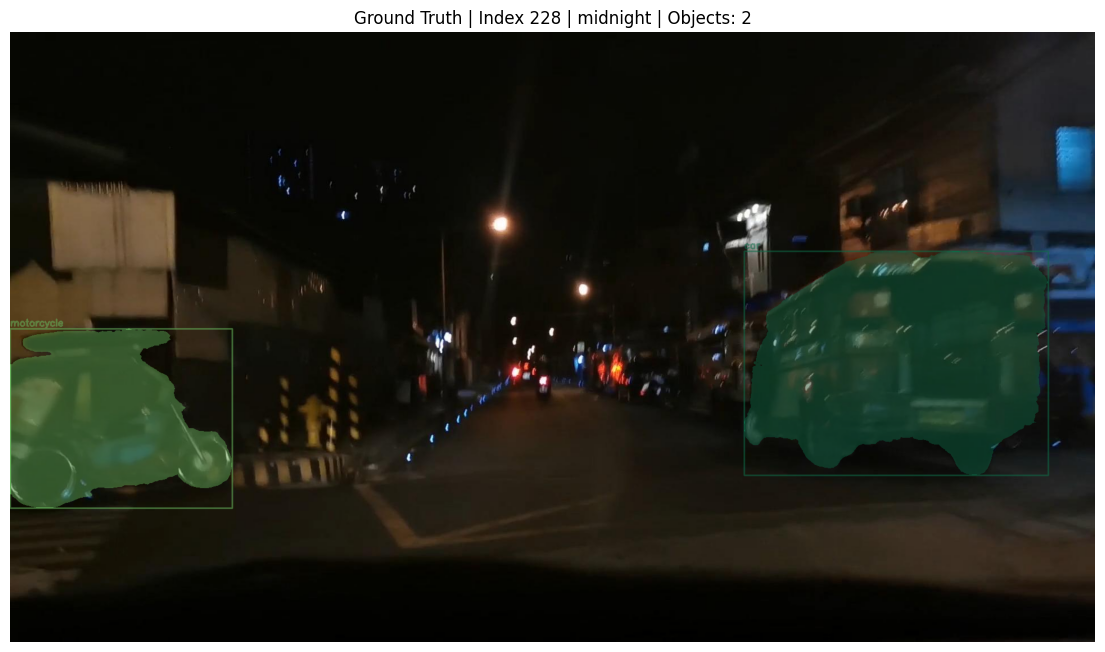

File: /content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/train/midnight/midnight_6fps_mp4-0235_jpg.rf.144ffd1a0844b8319e00baa66ff34cc2.jpg
Labels: ['motorcycle', 'car']


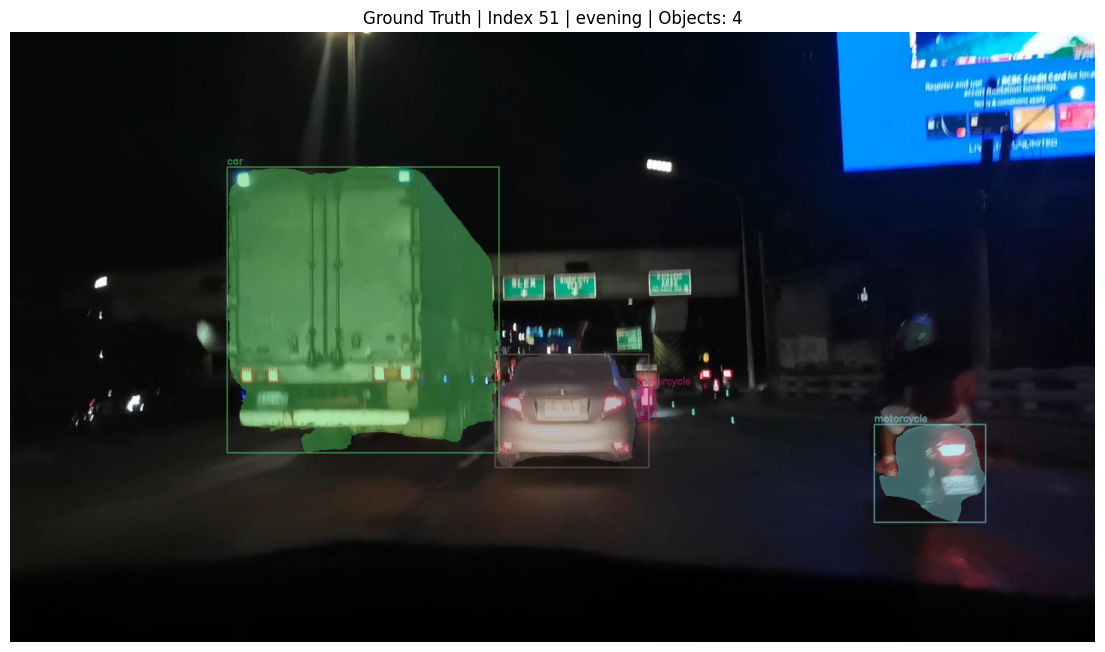

File: /content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/train/evening/evening_6fps_mp4-0069_jpg.rf.115c69e15d17e2f83cba12a96d5c0a85.jpg
Labels: ['motorcycle', 'motorcycle', 'car', 'car']


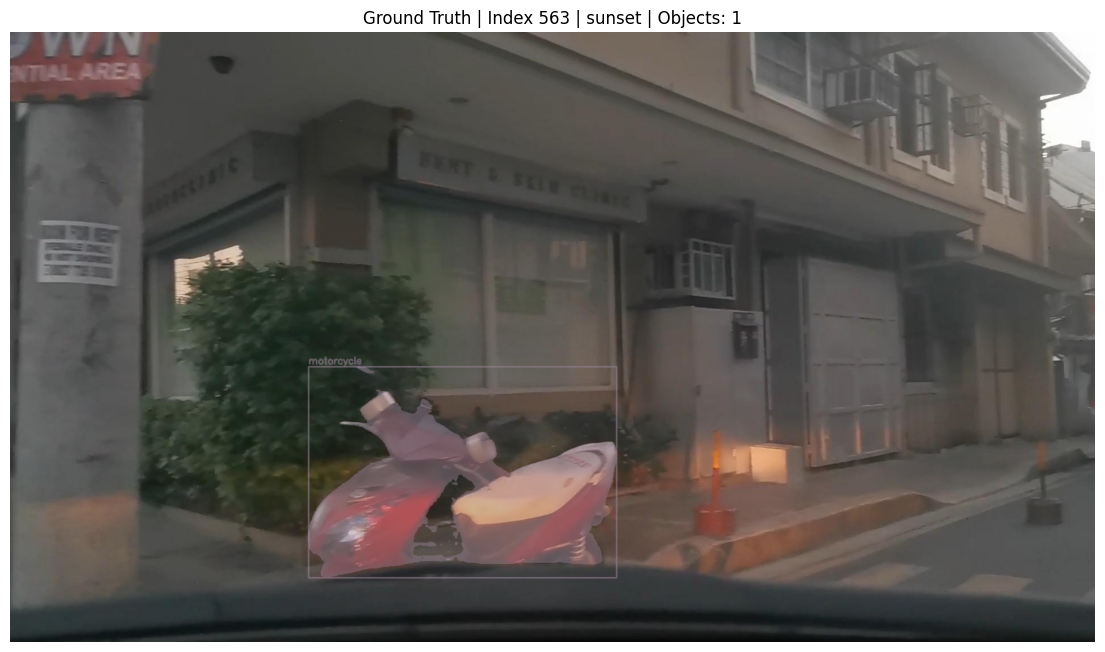

File: /content/drive/MyDrive/Thesis2/Thesis2_SUPER_FINAL_REANNOTATED_RawDataset/train/sunset/sunset_6fps_mp4-0101_jpg.rf.06484bfbb2d0667264b117b9e8f4b768.jpg
Labels: ['motorcycle']


In [24]:
def visualize_ground_truth(dataset, idx=None, alpha=0.45):
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    image_tensor, target = dataset[idx]

    image = image_tensor.permute(1, 2, 0).numpy()
    image_vis = (image * 255).astype(np.uint8).copy()
    overlay = image_vis.copy()

    boxes = target["boxes"].numpy()
    labels = target["labels"].numpy()
    masks = target["masks"].numpy()

    for i in range(len(boxes)):
        mask = masks[i].astype(bool)
        color = np.random.randint(0, 255, size=3).tolist()

        overlay[mask] = color

        x1, y1, x2, y2 = boxes[i].astype(int)
        class_name = idx_to_class.get(int(labels[i]), "unknown")

        cv2.rectangle(image_vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            image_vis,
            class_name,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2
        )

    blended = cv2.addWeighted(overlay, alpha, image_vis, 1 - alpha, 0)

    plt.figure(figsize=(14, 8))
    plt.imshow(blended)
    plt.axis("off")
    plt.title(f"Ground Truth | Index {idx} | {target['lighting_bin']} | Objects: {len(boxes)}")
    plt.show()

    print("File:", target["file_name"])
    print("Labels:", [idx_to_class[int(x)] for x in labels])

for _ in range(3):
    visualize_ground_truth(train_dataset)

In [26]:
USE_AUGMENTATION = False

if USE_AUGMENTATION:
    train_dataset_for_loader = LowLightAugmentedDataset(train_dataset)
else:
    train_dataset_for_loader = train_dataset

In [27]:
def collate_fn(batch):
    return tuple(zip(*batch))

BATCH_SIZE = 2
USE_BALANCED_SAMPLER = True

if USE_BALANCED_SAMPLER:
    train_loader = DataLoader(
        train_dataset_for_loader,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        collate_fn=collate_fn
    )
else:
    train_loader = DataLoader(
        train_dataset_for_loader,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        collate_fn=collate_fn
    )

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches:", len(test_loader))

Train batches: 577
Valid batches: 330
Test batches: 167


In [28]:
def get_mask_rcnn_fpn_model(num_classes):
    weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT

    model = maskrcnn_resnet50_fpn_v2(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes
    )

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

model = get_mask_rcnn_fpn_model(NUM_CLASSES)
model.to(device)

print("Model loaded on:", device)
print("Model transform:")
print(model.transform)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:01<00:00, 108MB/s]


Model loaded on: cuda
Model transform:
GeneralizedRCNNTransform(
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    Resize(min_size=(800,), max_size=1333, mode='bilinear')
)


Training Utilities

In [29]:
def move_target_to_device(target, device):
    return {
        "boxes": target["boxes"].to(device),
        "labels": target["labels"].to(device),
        "masks": target["masks"].to(device),
        "image_id": target["image_id"].to(device),
        "area": target["area"].to(device),
        "iscrowd": target["iscrowd"].to(device)
    }

In [30]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()

    totals = {
        "loss_total": 0.0,
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_mask": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0
    }

    for batch_idx, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [move_target_to_device(t, device) for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        totals["loss_total"] += losses.item()
        totals["loss_classifier"] += loss_dict["loss_classifier"].item()
        totals["loss_box_reg"] += loss_dict["loss_box_reg"].item()
        totals["loss_mask"] += loss_dict["loss_mask"].item()
        totals["loss_objectness"] += loss_dict["loss_objectness"].item()
        totals["loss_rpn_box_reg"] += loss_dict["loss_rpn_box_reg"].item()

        if batch_idx % 20 == 0:
            print(
                f"Epoch [{epoch}] Batch [{batch_idx}/{len(data_loader)}] "
                f"Loss: {losses.item():.4f}"
            )

    n = len(data_loader)
    return {k: v / n for k, v in totals.items()}

In [31]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()

    totals = {
        "loss_total": 0.0,
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_mask": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0
    }

    for batch_idx, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [move_target_to_device(t, device) for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        totals["loss_total"] += losses.item()
        totals["loss_classifier"] += loss_dict["loss_classifier"].item()
        totals["loss_box_reg"] += loss_dict["loss_box_reg"].item()
        totals["loss_mask"] += loss_dict["loss_mask"].item()
        totals["loss_objectness"] += loss_dict["loss_objectness"].item()
        totals["loss_rpn_box_reg"] += loss_dict["loss_rpn_box_reg"].item()

        if batch_idx % 20 == 0:
            print(
                f"Epoch [{epoch}] Batch [{batch_idx}/{len(data_loader)}] "
                f"Loss: {losses.item():.4f}"
            )

    n = len(data_loader)
    return {k: v / n for k, v in totals.items()}

In [38]:
@torch.no_grad()
def validate_loss(model, data_loader, device):
    model.train()

    totals = {
        "loss_total": 0.0,
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_mask": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0
    }

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [move_target_to_device(t, device) for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        totals["loss_total"] += losses.item()
        totals["loss_classifier"] += loss_dict["loss_classifier"].item()
        totals["loss_box_reg"] += loss_dict["loss_box_reg"].item()
        totals["loss_mask"] += loss_dict["loss_mask"].item()
        totals["loss_objectness"] += loss_dict["loss_objectness"].item()
        totals["loss_rpn_box_reg"] += loss_dict["loss_rpn_box_reg"].item()

    n = len(data_loader)
    return {k: v / n for k, v in totals.items()}

Prediction and Metric Functions

In [32]:
@torch.no_grad()
def predict_one(model, image_tensor, threshold=0.70):
    model.eval()

    prediction = model([image_tensor.to(device)])[0]

    scores = prediction["scores"].detach().cpu()
    keep = scores >= threshold

    filtered = {
        "boxes": prediction["boxes"].detach().cpu()[keep],
        "labels": prediction["labels"].detach().cpu()[keep],
        "scores": prediction["scores"].detach().cpu()[keep],
        "masks": prediction["masks"].detach().cpu()[keep]
    }

    return filtered

In [33]:
def box_iou_xyxy(box1, box2):
    x1 = max(float(box1[0]), float(box2[0]))
    y1 = max(float(box1[1]), float(box2[1]))
    x2 = min(float(box1[2]), float(box2[2]))
    y2 = min(float(box1[3]), float(box2[3]))

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    intersection = inter_w * inter_h

    area1 = max(0.0, float(box1[2]) - float(box1[0])) * max(0.0, float(box1[3]) - float(box1[1]))
    area2 = max(0.0, float(box2[2]) - float(box2[0])) * max(0.0, float(box2[3]) - float(box2[1]))

    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return intersection / union

In [34]:
def match_predictions_to_ground_truth(pred_boxes, pred_labels, gt_boxes, gt_labels, iou_threshold=0.50):
    pred_boxes = pred_boxes.numpy() if torch.is_tensor(pred_boxes) else pred_boxes
    pred_labels = pred_labels.numpy() if torch.is_tensor(pred_labels) else pred_labels
    gt_boxes = gt_boxes.numpy() if torch.is_tensor(gt_boxes) else gt_boxes
    gt_labels = gt_labels.numpy() if torch.is_tensor(gt_labels) else gt_labels

    matched_gt = set()

    tp = 0
    fp = 0

    for pred_idx, pred_box in enumerate(pred_boxes):
        pred_label = pred_labels[pred_idx]

        best_iou = 0.0
        best_gt_idx = None

        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue

            gt_label = gt_labels[gt_idx]

            if pred_label != gt_label:
                continue

            iou = box_iou_xyxy(pred_box, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold and best_gt_idx is not None:
            tp += 1
            matched_gt.add(best_gt_idx)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    return tp, fp, fn

In [35]:
@torch.no_grad()
def evaluate_precision_recall_f1(model, dataset, threshold=0.70, iou_threshold=0.50):
    total_tp = 0
    total_fp = 0
    total_fn = 0

    per_image_results = []

    for idx in range(len(dataset)):
        image_tensor, target = dataset[idx]
        prediction = predict_one(model, image_tensor, threshold=threshold)

        tp, fp, fn = match_predictions_to_ground_truth(
            prediction["boxes"],
            prediction["labels"],
            target["boxes"],
            target["labels"],
            iou_threshold=iou_threshold
        )

        total_tp += tp
        total_fp += fp
        total_fn += fn

        per_image_results.append({
            "image_index": idx,
            "file_name": target["file_name"],
            "lighting_bin": target["lighting_bin"],
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "num_gt": int(len(target["boxes"])),
            "num_pred": int(len(prediction["boxes"]))
        })

        if idx % 50 == 0:
            print(f"Evaluated {idx}/{len(dataset)}")

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    metrics = {
        "confidence_threshold": float(threshold),
        "iou_threshold": float(iou_threshold),
        "tp": int(total_tp),
        "fp": int(total_fp),
        "fn": int(total_fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1)
    }

    return metrics, per_image_results

Phase 1 Training: Frozen Backbone

In [36]:
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

PHASE1_EPOCHS = 8
OFFICIAL_THRESHOLD = 0.70
IOU_THRESHOLD = 0.50

best_valid_f1 = -1.0
history = []

BEST_PATH = OUTPUT_DIR / "maskrcnn_fpn_super_final_best.pth"

In [39]:
for epoch in range(1, PHASE1_EPOCHS + 1):
    train_losses = train_one_epoch(model, optimizer, train_loader, device, epoch)
    valid_losses = validate_loss(model, valid_loader, device)

    valid_metrics, valid_per_image = evaluate_precision_recall_f1(
        model,
        valid_dataset,
        threshold=OFFICIAL_THRESHOLD,
        iou_threshold=IOU_THRESHOLD
    )

    scheduler.step()

    row = {
        "phase": "frozen_backbone",
        "epoch": epoch,
        **{f"train_{k}": v for k, v in train_losses.items()},
        **{f"valid_{k}": v for k, v in valid_losses.items()},
        "valid_precision": valid_metrics["precision"],
        "valid_recall": valid_metrics["recall"],
        "valid_f1_score": valid_metrics["f1_score"]
    }

    history.append(row)

    print("\n==============================")
    print(f"Phase 1 Epoch {epoch}/{PHASE1_EPOCHS}")
    print("Train loss:", train_losses["loss_total"])
    print("Valid loss:", valid_losses["loss_total"])
    print("Valid precision:", valid_metrics["precision"])
    print("Valid recall:", valid_metrics["recall"])
    print("Valid F1:", valid_metrics["f1_score"])

    checkpoint = {
        "phase": "frozen_backbone",
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class,
        "num_classes": NUM_CLASSES,
        "history": history,
        "valid_metrics": valid_metrics,
        "sampler_weights": {
            "motorcycle_weight": 1.60,
            "person_weight": 1.15,
            "motorcycle_person_extra_weight": 1.20,
            "midnight_weight": 1.35,
            "motorcycle_midnight_extra_weight": 1.30
        },
        "augmentation_enabled": USE_AUGMENTATION
    }

    torch.save(checkpoint, OUTPUT_DIR / f"phase1_epoch_{epoch}.pth")

    if valid_metrics["f1_score"] > best_valid_f1:
        best_valid_f1 = valid_metrics["f1_score"]
        torch.save(checkpoint, BEST_PATH)
        print("Saved new best model.")

Epoch [1] Batch [0/577] Loss: 0.6374
Epoch [1] Batch [20/577] Loss: 0.9130
Epoch [1] Batch [40/577] Loss: 0.6275
Epoch [1] Batch [60/577] Loss: 0.7334
Epoch [1] Batch [80/577] Loss: 0.5710
Epoch [1] Batch [100/577] Loss: 0.8163
Epoch [1] Batch [120/577] Loss: 0.5492
Epoch [1] Batch [140/577] Loss: 0.5981
Epoch [1] Batch [160/577] Loss: 0.9017
Epoch [1] Batch [180/577] Loss: 0.5142
Epoch [1] Batch [200/577] Loss: 0.6044
Epoch [1] Batch [220/577] Loss: 0.7346
Epoch [1] Batch [240/577] Loss: 0.9985
Epoch [1] Batch [260/577] Loss: 0.5906
Epoch [1] Batch [280/577] Loss: 0.5037
Epoch [1] Batch [300/577] Loss: 0.6407
Epoch [1] Batch [320/577] Loss: 0.5620
Epoch [1] Batch [340/577] Loss: 0.6031
Epoch [1] Batch [360/577] Loss: 0.6686
Epoch [1] Batch [380/577] Loss: 0.6667
Epoch [1] Batch [400/577] Loss: 0.5823
Epoch [1] Batch [420/577] Loss: 0.6461
Epoch [1] Batch [440/577] Loss: 0.8901
Epoch [1] Batch [460/577] Loss: 0.4519
Epoch [1] Batch [480/577] Loss: 0.6645
Epoch [1] Batch [500/577] Loss:

Phase 2: Unfreeze Backbone

In [40]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.0001,
    momentum=0.9,
    weight_decay=0.0005
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

PHASE2_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 4
epochs_without_improvement = 0

In [41]:
for epoch in range(1, PHASE2_EPOCHS + 1):
    global_epoch = PHASE1_EPOCHS + epoch

    train_losses = train_one_epoch(model, optimizer, train_loader, device, global_epoch)
    valid_losses = validate_loss(model, valid_loader, device)

    valid_metrics, valid_per_image = evaluate_precision_recall_f1(
        model,
        valid_dataset,
        threshold=OFFICIAL_THRESHOLD,
        iou_threshold=IOU_THRESHOLD
    )

    valid_f1 = valid_metrics["f1_score"]
    scheduler.step(valid_f1)

    row = {
        "phase": "unfrozen_backbone",
        "epoch": global_epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **{f"train_{k}": v for k, v in train_losses.items()},
        **{f"valid_{k}": v for k, v in valid_losses.items()},
        "valid_precision": valid_metrics["precision"],
        "valid_recall": valid_metrics["recall"],
        "valid_f1_score": valid_metrics["f1_score"]
    }

    history.append(row)

    print("\n==============================")
    print(f"Phase 2 Epoch {epoch}/{PHASE2_EPOCHS}")
    print("Global epoch:", global_epoch)
    print("LR:", optimizer.param_groups[0]["lr"])
    print("Train loss:", train_losses["loss_total"])
    print("Valid loss:", valid_losses["loss_total"])
    print("Valid precision:", valid_metrics["precision"])
    print("Valid recall:", valid_metrics["recall"])
    print("Valid F1:", valid_f1)

    checkpoint = {
        "phase": "unfrozen_backbone",
        "epoch": global_epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class,
        "num_classes": NUM_CLASSES,
        "history": history,
        "valid_metrics": valid_metrics,
        "sampler_weights": {
            "motorcycle_weight": 1.60,
            "person_weight": 1.15,
            "motorcycle_person_extra_weight": 1.20,
            "midnight_weight": 1.35,
            "motorcycle_midnight_extra_weight": 1.30
        },
        "augmentation_enabled": USE_AUGMENTATION
    }

    torch.save(checkpoint, OUTPUT_DIR / f"phase2_epoch_{global_epoch}.pth")

    if valid_f1 > best_valid_f1:
        best_valid_f1 = valid_f1
        epochs_without_improvement = 0
        torch.save(checkpoint, BEST_PATH)
        print("Saved new best model.")
    else:
        epochs_without_improvement += 1
        print("No F1 improvement:", epochs_without_improvement)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

Epoch [9] Batch [0/577] Loss: 0.3726
Epoch [9] Batch [20/577] Loss: 0.2411
Epoch [9] Batch [40/577] Loss: 0.6939
Epoch [9] Batch [60/577] Loss: 0.1776
Epoch [9] Batch [80/577] Loss: 0.2929
Epoch [9] Batch [100/577] Loss: 0.3996
Epoch [9] Batch [120/577] Loss: 0.6201
Epoch [9] Batch [140/577] Loss: 0.7190
Epoch [9] Batch [160/577] Loss: 0.3326
Epoch [9] Batch [180/577] Loss: 0.2795
Epoch [9] Batch [200/577] Loss: 0.1704
Epoch [9] Batch [220/577] Loss: 0.3318
Epoch [9] Batch [240/577] Loss: 0.5548
Epoch [9] Batch [260/577] Loss: 0.2404
Epoch [9] Batch [280/577] Loss: 0.3431
Epoch [9] Batch [300/577] Loss: 0.2737
Epoch [9] Batch [320/577] Loss: 0.5196
Epoch [9] Batch [340/577] Loss: 0.2145
Epoch [9] Batch [360/577] Loss: 0.2788
Epoch [9] Batch [380/577] Loss: 0.3230
Epoch [9] Batch [400/577] Loss: 0.4544
Epoch [9] Batch [420/577] Loss: 0.3929
Epoch [9] Batch [440/577] Loss: 0.4330
Epoch [9] Batch [460/577] Loss: 0.2941
Epoch [9] Batch [480/577] Loss: 0.2654
Epoch [9] Batch [500/577] Loss:

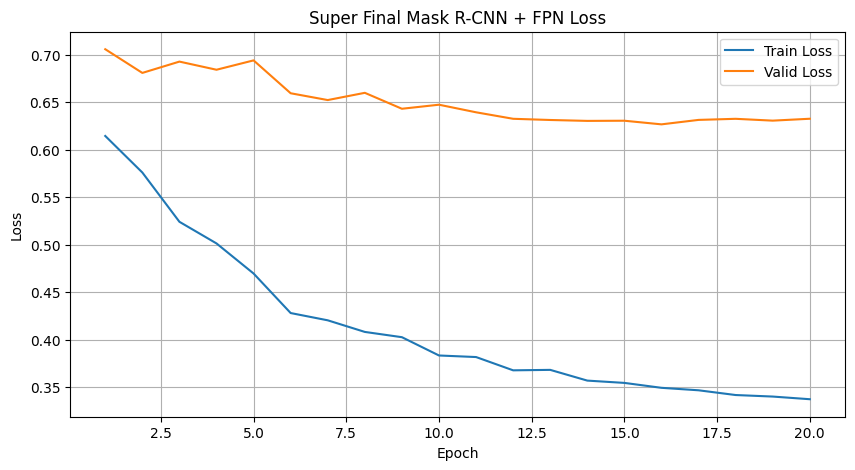

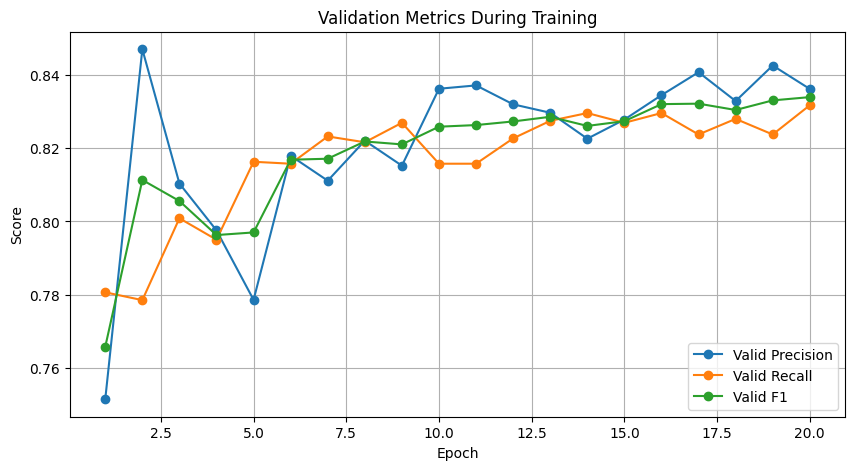

In [42]:
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss_total"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss_total"], label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Super Final Mask R-CNN + FPN Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["valid_precision"], marker="o", label="Valid Precision")
plt.plot(history_df["epoch"], history_df["valid_recall"], marker="o", label="Valid Recall")
plt.plot(history_df["epoch"], history_df["valid_f1_score"], marker="o", label="Valid F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics During Training")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
best_checkpoint = torch.load(BEST_PATH, map_location=device)

best_model = get_mask_rcnn_fpn_model(NUM_CLASSES)
best_model.load_state_dict(best_checkpoint["model_state_dict"])
best_model.to(device)
best_model.eval()

print("Loaded best model:")
print(BEST_PATH)
print("Best epoch:", best_checkpoint["epoch"])
print("Best phase:", best_checkpoint["phase"])
print("Best validation metrics:")
print(json.dumps(best_checkpoint["valid_metrics"], indent=2))

Loaded best model:
/content/drive/MyDrive/Thesis2/outputs_maskrcnn_fpn_super_final_reannotated/maskrcnn_fpn_super_final_best.pth
Best epoch: 20
Best phase: unfrozen_backbone
Best validation metrics:
{
  "confidence_threshold": 0.7,
  "iou_threshold": 0.5,
  "tp": 1562,
  "fp": 306,
  "fn": 316,
  "precision": 0.8361884368308351,
  "recall": 0.8317358892438764,
  "f1_score": 0.8339562199679659
}


In [44]:
final_valid_metrics, final_valid_per_image = evaluate_precision_recall_f1(
    best_model,
    valid_dataset,
    threshold=OFFICIAL_THRESHOLD,
    iou_threshold=IOU_THRESHOLD
)

final_test_metrics, final_test_per_image = evaluate_precision_recall_f1(
    best_model,
    test_dataset,
    threshold=OFFICIAL_THRESHOLD,
    iou_threshold=IOU_THRESHOLD
)

print("Final validation metrics @ 0.70:")
print(json.dumps(final_valid_metrics, indent=2))

print("\nFinal test metrics @ 0.70:")
print(json.dumps(final_test_metrics, indent=2))

with open(OUTPUT_DIR / "final_valid_metrics_070.json", "w") as f:
    json.dump(final_valid_metrics, f, indent=2)

with open(OUTPUT_DIR / "final_test_metrics_070.json", "w") as f:
    json.dump(final_test_metrics, f, indent=2)

pd.DataFrame(final_valid_per_image).to_csv(OUTPUT_DIR / "final_valid_per_image_070.csv", index=False)
pd.DataFrame(final_test_per_image).to_csv(OUTPUT_DIR / "final_test_per_image_070.csv", index=False)

Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330
Evaluated 0/167
Evaluated 50/167
Evaluated 100/167
Evaluated 150/167
Final validation metrics @ 0.70:
{
  "confidence_threshold": 0.7,
  "iou_threshold": 0.5,
  "tp": 1562,
  "fp": 306,
  "fn": 316,
  "precision": 0.8361884368308351,
  "recall": 0.8317358892438764,
  "f1_score": 0.8339562199679659
}

Final test metrics @ 0.70:
{
  "confidence_threshold": 0.7,
  "iou_threshold": 0.5,
  "tp": 812,
  "fp": 145,
  "fn": 162,
  "precision": 0.8484848484848485,
  "recall": 0.8336755646817249,
  "f1_score": 0.8410150181253235
}


In [45]:
def summarize_by_lighting_bin(per_image_results):
    df = pd.DataFrame(per_image_results)
    rows = []

    for lighting_bin, group in df.groupby("lighting_bin"):
        tp = group["tp"].sum()
        fp = group["fp"].sum()
        fn = group["fn"].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "lighting_bin": lighting_bin,
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1),
            "num_images": int(len(group))
        })

    return pd.DataFrame(rows)

final_valid_lighting = summarize_by_lighting_bin(final_valid_per_image)
final_test_lighting = summarize_by_lighting_bin(final_test_per_image)

print("Validation by lighting:")
display(final_valid_lighting)

print("Test by lighting:")
display(final_test_lighting)

final_valid_lighting.to_csv(OUTPUT_DIR / "final_valid_lighting_070.csv", index=False)
final_test_lighting.to_csv(OUTPUT_DIR / "final_test_lighting_070.csv", index=False)

Validation by lighting:


,lighting_bin,tp,fp,fn,precision,recall,f1_score,num_images
0,evening,170,51,43,0.769231,0.798122,0.783410,40
1,midnight,267,53,91,0.834375,0.745810,0.787611,77
2,sunset,1125,202,182,0.847777,0.860750,0.854214,213


Test by lighting:


,lighting_bin,tp,fp,fn,precision,recall,f1_score,num_images
0,evening,92,21,21,0.814159,0.814159,0.814159,20
1,midnight,131,34,54,0.793939,0.708108,0.748571,39
2,sunset,589,90,87,0.867452,0.871302,0.869373,108


In [46]:
@torch.no_grad()
def evaluate_per_class_metrics(model, dataset, threshold=0.70, iou_threshold=0.50):
    class_stats = {
        class_id: {"tp": 0, "fp": 0, "fn": 0}
        for class_id in idx_to_class.keys()
    }

    for idx in range(len(dataset)):
        image_tensor, target = dataset[idx]
        prediction = predict_one(model, image_tensor, threshold=threshold)

        gt_boxes = target["boxes"]
        gt_labels = target["labels"]
        pred_boxes = prediction["boxes"]
        pred_labels = prediction["labels"]

        for class_id in idx_to_class.keys():
            gt_mask = gt_labels == class_id
            pred_mask = pred_labels == class_id

            class_gt_boxes = gt_boxes[gt_mask]
            class_gt_labels = gt_labels[gt_mask]

            class_pred_boxes = pred_boxes[pred_mask]
            class_pred_labels = pred_labels[pred_mask]

            tp, fp, fn = match_predictions_to_ground_truth(
                class_pred_boxes,
                class_pred_labels,
                class_gt_boxes,
                class_gt_labels,
                iou_threshold=iou_threshold
            )

            class_stats[class_id]["tp"] += tp
            class_stats[class_id]["fp"] += fp
            class_stats[class_id]["fn"] += fn

    rows = []

    for class_id, stats in class_stats.items():
        tp = stats["tp"]
        fp = stats["fp"]
        fn = stats["fn"]

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "class_id": int(class_id),
            "class_name": idx_to_class[class_id],
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1)
        })

    return pd.DataFrame(rows)

final_valid_class = evaluate_per_class_metrics(
    best_model,
    valid_dataset,
    threshold=OFFICIAL_THRESHOLD,
    iou_threshold=IOU_THRESHOLD
)

final_test_class = evaluate_per_class_metrics(
    best_model,
    test_dataset,
    threshold=OFFICIAL_THRESHOLD,
    iou_threshold=IOU_THRESHOLD
)

print("Validation by class:")
display(final_valid_class)

print("Test by class:")
display(final_test_class)

final_valid_class.to_csv(OUTPUT_DIR / "final_valid_class_070.csv", index=False)
final_test_class.to_csv(OUTPUT_DIR / "final_test_class_070.csv", index=False)

Validation by class:


,class_id,class_name,tp,fp,fn,precision,recall,f1_score
0,1,car,741,76,127,0.906977,0.853687,0.879525
1,2,motorcycle,391,96,81,0.802875,0.828390,0.815433
2,3,person,430,134,108,0.762411,0.799257,0.780399


Test by class:


,class_id,class_name,tp,fp,fn,precision,recall,f1_score
0,1,car,417,47,68,0.898707,0.859794,0.878820
1,2,motorcycle,167,51,46,0.766055,0.784038,0.774942
2,3,person,228,47,48,0.829091,0.826087,0.827586



Evaluating threshold: 0.4
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330

Evaluating threshold: 0.5
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330

Evaluating threshold: 0.6
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330

Evaluating threshold: 0.65
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330

Evaluating threshold: 0.7
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330

Evaluating threshold: 0.75
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Evaluated 200/330
Evaluated 250/330
Evaluated 300/330

Evaluating threshold: 0.8
Evaluated 0/330
Evaluated 50/330
Evaluated 100/330
Evaluated 150/330
Ev

,confidence_threshold,iou_threshold,tp,fp,fn,precision,recall,f1_score
0,0.40,0.5,1637,615,241,0.726909,0.871672,0.792736
1,0.50,0.5,1615,485,263,0.769048,0.859957,0.811966
2,0.60,0.5,1586,382,292,0.805894,0.844515,0.824753
3,0.65,0.5,1577,340,301,0.822640,0.839723,0.831094
4,0.70,0.5,1562,306,316,0.836188,0.831736,0.833956
5,0.75,0.5,1543,276,335,0.848268,0.821619,0.834731
6,0.80,0.5,1507,241,371,0.862128,0.802449,0.831219
7,0.90,0.5,1405,163,473,0.896046,0.748136,0.815438


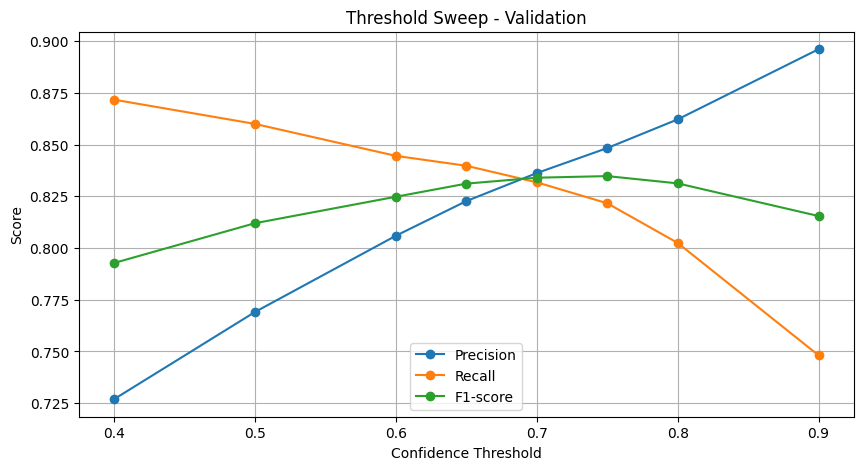

Best validation threshold: 0.75


,5
confidence_threshold,0.750000
iou_threshold,0.500000
tp,1543.000000
fp,276.000000
fn,335.000000
precision,0.848268
recall,0.821619
f1_score,0.834731


Evaluated 0/167
Evaluated 50/167
Evaluated 100/167
Evaluated 150/167
Test metrics at best validation threshold:
{
  "confidence_threshold": 0.75,
  "iou_threshold": 0.5,
  "tp": 800,
  "fp": 126,
  "fn": 174,
  "precision": 0.8639308855291576,
  "recall": 0.8213552361396304,
  "f1_score": 0.8421052631578947
}


In [47]:
THRESHOLDS = [0.40, 0.50, 0.60, 0.65, 0.70, 0.75, 0.80, 0.90]

threshold_results = []

for threshold in THRESHOLDS:
    print("\nEvaluating threshold:", threshold)

    metrics, _ = evaluate_precision_recall_f1(
        best_model,
        valid_dataset,
        threshold=threshold,
        iou_threshold=IOU_THRESHOLD
    )

    threshold_results.append(metrics)

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

threshold_df.to_csv(OUTPUT_DIR / "threshold_sweep_valid.csv", index=False)

plt.figure(figsize=(10, 5))
plt.plot(threshold_df["confidence_threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["confidence_threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["confidence_threshold"], threshold_df["f1_score"], marker="o", label="F1-score")
plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep - Validation")
plt.legend()
plt.grid(True)
plt.show()

best_threshold_row = threshold_df.sort_values("f1_score", ascending=False).iloc[0]
BEST_THRESHOLD = float(best_threshold_row["confidence_threshold"])

print("Best validation threshold:", BEST_THRESHOLD)
display(best_threshold_row)

test_best_threshold_metrics, _ = evaluate_precision_recall_f1(
    best_model,
    test_dataset,
    threshold=BEST_THRESHOLD,
    iou_threshold=IOU_THRESHOLD
)

print("Test metrics at best validation threshold:")
print(json.dumps(test_best_threshold_metrics, indent=2))

In [48]:
@torch.no_grad()
def collect_predictions_for_ap(model, dataset, threshold=0.05, iou_threshold=0.50):
    all_rows = []
    gt_count_by_class = {class_id: 0 for class_id in idx_to_class.keys()}

    for img_idx in range(len(dataset)):
        image_tensor, target = dataset[img_idx]
        prediction = predict_one(model, image_tensor, threshold=threshold)

        gt_boxes = target["boxes"]
        gt_labels = target["labels"]

        pred_boxes = prediction["boxes"]
        pred_labels = prediction["labels"]
        pred_scores = prediction["scores"]

        for class_id in idx_to_class.keys():
            gt_count_by_class[class_id] += int((gt_labels == class_id).sum().item())

        for class_id in idx_to_class.keys():
            class_pred_mask = pred_labels == class_id
            class_gt_mask = gt_labels == class_id

            class_pred_boxes = pred_boxes[class_pred_mask]
            class_pred_scores = pred_scores[class_pred_mask]
            class_gt_boxes = gt_boxes[class_gt_mask]

            if len(class_pred_scores) > 0:
                sorted_indices = torch.argsort(class_pred_scores, descending=True)
                class_pred_boxes = class_pred_boxes[sorted_indices]
                class_pred_scores = class_pred_scores[sorted_indices]

            matched_gt = set()

            for pred_i in range(len(class_pred_boxes)):
                pred_box = class_pred_boxes[pred_i]
                pred_score = float(class_pred_scores[pred_i].item())

                best_iou = 0.0
                best_gt_idx = None

                for gt_i, gt_box in enumerate(class_gt_boxes):
                    if gt_i in matched_gt:
                        continue

                    iou = box_iou_xyxy(pred_box, gt_box)

                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = gt_i

                is_tp = 0

                if best_iou >= iou_threshold and best_gt_idx is not None:
                    is_tp = 1
                    matched_gt.add(best_gt_idx)

                all_rows.append({
                    "image_index": img_idx,
                    "class_id": class_id,
                    "class_name": idx_to_class[class_id],
                    "score": pred_score,
                    "tp": is_tp,
                    "fp": 1 - is_tp,
                    "best_iou": float(best_iou)
                })

    pred_df = pd.DataFrame(all_rows)

    return pred_df, gt_count_by_class

In [49]:
def compute_ap_from_predictions(pred_df, gt_count_by_class):
    rows = []

    for class_id, class_name in idx_to_class.items():
        class_df = pred_df[pred_df["class_id"] == class_id].copy()
        class_df = class_df.sort_values("score", ascending=False)

        n_gt = gt_count_by_class[class_id]

        if len(class_df) == 0 or n_gt == 0:
            rows.append({
                "class_id": class_id,
                "class_name": class_name,
                "num_gt": n_gt,
                "ap50": 0.0
            })
            continue

        tp_cumsum = class_df["tp"].cumsum().values
        fp_cumsum = class_df["fp"].cumsum().values

        recalls = tp_cumsum / max(n_gt, 1)
        precisions = tp_cumsum / np.maximum(tp_cumsum + fp_cumsum, 1)

        mrec = np.concatenate(([0.0], recalls, [1.0]))
        mpre = np.concatenate(([0.0], precisions, [0.0]))

        for i in range(len(mpre) - 2, -1, -1):
            mpre[i] = max(mpre[i], mpre[i + 1])

        changing_points = np.where(mrec[1:] != mrec[:-1])[0]
        ap = np.sum((mrec[changing_points + 1] - mrec[changing_points]) * mpre[changing_points + 1])

        rows.append({
            "class_id": class_id,
            "class_name": class_name,
            "num_gt": n_gt,
            "ap50": float(ap)
        })

    ap_df = pd.DataFrame(rows)
    map50 = ap_df["ap50"].mean()

    return ap_df, map50

In [50]:
valid_pred_df, valid_gt_counts = collect_predictions_for_ap(
    best_model,
    valid_dataset,
    threshold=0.05,
    iou_threshold=0.50
)

valid_ap_df, valid_map50 = compute_ap_from_predictions(
    valid_pred_df,
    valid_gt_counts
)

test_pred_df, test_gt_counts = collect_predictions_for_ap(
    best_model,
    test_dataset,
    threshold=0.05,
    iou_threshold=0.50
)

test_ap_df, test_map50 = compute_ap_from_predictions(
    test_pred_df,
    test_gt_counts
)

print("Validation AP50 by class:")
display(valid_ap_df)
print("Validation mAP50:", valid_map50)

print("\nTest AP50 by class:")
display(test_ap_df)
print("Test mAP50:", test_map50)

valid_ap_df.to_csv(OUTPUT_DIR / "final_valid_ap50_by_class.csv", index=False)
test_ap_df.to_csv(OUTPUT_DIR / "final_test_ap50_by_class.csv", index=False)

with open(OUTPUT_DIR / "final_map50_summary.json", "w") as f:
    json.dump({
        "valid_map50": float(valid_map50),
        "test_map50": float(test_map50)
    }, f, indent=2)

Validation AP50 by class:


,class_id,class_name,num_gt,ap50
0,1,car,868,0.925542
1,2,motorcycle,472,0.820102
2,3,person,538,0.783465


Validation mAP50: 0.8430360974715546

Test AP50 by class:


,class_id,class_name,num_gt,ap50
0,1,car,485,0.928999
1,2,motorcycle,213,0.805985
2,3,person,276,0.836613


Test mAP50: 0.8571988319489005


In [51]:
FINAL_MODEL_DIR = OUTPUT_DIR / "final_known_object_model"
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_PATH = FINAL_MODEL_DIR / "maskrcnn_fpn_known_objects_super_final.pth"

final_package = {
    "model_state_dict": best_model.state_dict(),
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "num_classes": NUM_CLASSES,
    "official_threshold": OFFICIAL_THRESHOLD,
    "best_threshold": BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else None,
    "iou_threshold": IOU_THRESHOLD,
    "valid_metrics_070": final_valid_metrics,
    "test_metrics_070": final_test_metrics,
    "test_metrics_best_threshold": test_best_threshold_metrics if "test_best_threshold_metrics" in globals() else None,
    "valid_lighting_070": final_valid_lighting.to_dict(orient="records"),
    "test_lighting_070": final_test_lighting.to_dict(orient="records"),
    "valid_class_070": final_valid_class.to_dict(orient="records"),
    "test_class_070": final_test_class.to_dict(orient="records"),
    "valid_map50": float(valid_map50) if "valid_map50" in globals() else None,
    "test_map50": float(test_map50) if "test_map50" in globals() else None,
    "source_checkpoint": str(BEST_PATH),
    "ignored_classes": list(IGNORED_CLASSES),
    "training_notes": {
        "model": "Mask R-CNN ResNet50 FPN V2",
        "pretraining": "COCO",
        "classes": CLASS_NAMES,
        "unknown_object_policy": "ignored during Mask R-CNN training; reserved for CaVi-style depth anomaly detection",
        "confidence_threshold": 0.70,
        "weighted_sampling": True,
        "augmentation_enabled": USE_AUGMENTATION
    }
}

torch.save(final_package, FINAL_MODEL_PATH)

print("Final known-object model saved at:")
print(FINAL_MODEL_PATH)

Final known-object model saved at:
/content/drive/MyDrive/Thesis2/outputs_maskrcnn_fpn_super_final_reannotated/final_known_object_model/maskrcnn_fpn_known_objects_super_final.pth


In [52]:
print("===== SUPER FINAL KNOWN-OBJECT MASK R-CNN + FPN =====")

print("\nModel path:")
print(FINAL_MODEL_PATH)

print("\nValidation metrics @ 0.70:")
print(json.dumps(final_valid_metrics, indent=2))

print("\nTest metrics @ 0.70:")
print(json.dumps(final_test_metrics, indent=2))

print("\nTest metrics at best validation threshold:")
print(json.dumps(test_best_threshold_metrics, indent=2))

print("\nValidation by lighting:")
display(final_valid_lighting)

print("\nTest by lighting:")
display(final_test_lighting)

print("\nValidation by class:")
display(final_valid_class)

print("\nTest by class:")
display(final_test_class)

print("\nValidation AP50:")
display(valid_ap_df)
print("Validation mAP50:", valid_map50)

print("\nTest AP50:")
display(test_ap_df)
print("Test mAP50:", test_map50)

===== SUPER FINAL KNOWN-OBJECT MASK R-CNN + FPN =====

Model path:
/content/drive/MyDrive/Thesis2/outputs_maskrcnn_fpn_super_final_reannotated/final_known_object_model/maskrcnn_fpn_known_objects_super_final.pth

Validation metrics @ 0.70:
{
  "confidence_threshold": 0.7,
  "iou_threshold": 0.5,
  "tp": 1562,
  "fp": 306,
  "fn": 316,
  "precision": 0.8361884368308351,
  "recall": 0.8317358892438764,
  "f1_score": 0.8339562199679659
}

Test metrics @ 0.70:
{
  "confidence_threshold": 0.7,
  "iou_threshold": 0.5,
  "tp": 812,
  "fp": 145,
  "fn": 162,
  "precision": 0.8484848484848485,
  "recall": 0.8336755646817249,
  "f1_score": 0.8410150181253235
}

Test metrics at best validation threshold:
{
  "confidence_threshold": 0.75,
  "iou_threshold": 0.5,
  "tp": 800,
  "fp": 126,
  "fn": 174,
  "precision": 0.8639308855291576,
  "recall": 0.8213552361396304,
  "f1_score": 0.8421052631578947
}

Validation by lighting:


,lighting_bin,tp,fp,fn,precision,recall,f1_score,num_images
0,evening,170,51,43,0.769231,0.798122,0.783410,40
1,midnight,267,53,91,0.834375,0.745810,0.787611,77
2,sunset,1125,202,182,0.847777,0.860750,0.854214,213



Test by lighting:


,lighting_bin,tp,fp,fn,precision,recall,f1_score,num_images
0,evening,92,21,21,0.814159,0.814159,0.814159,20
1,midnight,131,34,54,0.793939,0.708108,0.748571,39
2,sunset,589,90,87,0.867452,0.871302,0.869373,108



Validation by class:


...


Validation AP50:


,class_id,class_name,num_gt,ap50
0,1,car,868,0.925542
1,2,motorcycle,472,0.820102
2,3,person,538,0.783465


Validation mAP50: 0.8430360974715546

Test AP50:


,class_id,class_name,num_gt,ap50
0,1,car,485,0.928999
1,2,motorcycle,213,0.805985
2,3,person,276,0.836613


Test mAP50: 0.8571988319489005
